In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
SAVE_DIR = 'outputs/'
PALETTE = ['#2196F3','#FF5722','#4CAF50', '#9C27B0','#FF9800', '#F1DB31']

# load dataset
df = pd.read_csv('Airline_Delay_Cause.csv', encoding='utf-8')
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [2]:
# df.info()
# df.describe().round(2)

In [3]:
# cleaning and preprocessing
str_cols = df.select_dtypes('object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with missing values:')
print(missing_df if not missing_df.empty else 'Clean dataset')

delay_cols = ['arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
df_clean = df.dropna(subset = delay_cols).copy()

month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun', 7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df_clean['month_name'] = df_clean['month'].map(month_map)

print('Clean dataset:', df_clean.shape)
df_clean.head()

Columns with missing values:
                     Missing Count  Missing %
arr_del15                      443       0.26
arr_flights                    240       0.14
carrier_ct                     240       0.14
weather_ct                     240       0.14
nas_ct                         240       0.14
security_ct                    240       0.14
late_aircraft_ct               240       0.14
arr_cancelled                  240       0.14
arr_diverted                   240       0.14
arr_delay                      240       0.14
carrier_delay                  240       0.14
weather_delay                  240       0.14
nas_delay                      240       0.14
security_delay                 240       0.14
late_aircraft_delay            240       0.14
Clean dataset: (171426, 22)


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,month_name
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0,Aug
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0,Aug
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0,Aug
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0,Aug
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0,Aug


In [4]:
delay_cause_cols = ['carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct']
delay_min_cols = ['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']
cause_labels = ['Carrier','Weather','NAS','Security','Late A/C']

# Derived features
df_clean['delay_rate'] = df_clean['arr_del15'] / df_clean['arr_flights']
df_clean['cancel_rate'] = df_clean['arr_cancelled'] / df_clean['arr_flights']
df_clean['avg_delay_min'] = df_clean['arr_delay'] / df_clean['arr_del15'].replace(0, np.nan)
df_clean['total_delay_ct'] = (df_clean['carrier_ct'] + df_clean['weather_ct'] + df_clean['nas_ct'] + df_clean['security_ct'] + df_clean['late_aircraft_ct'])

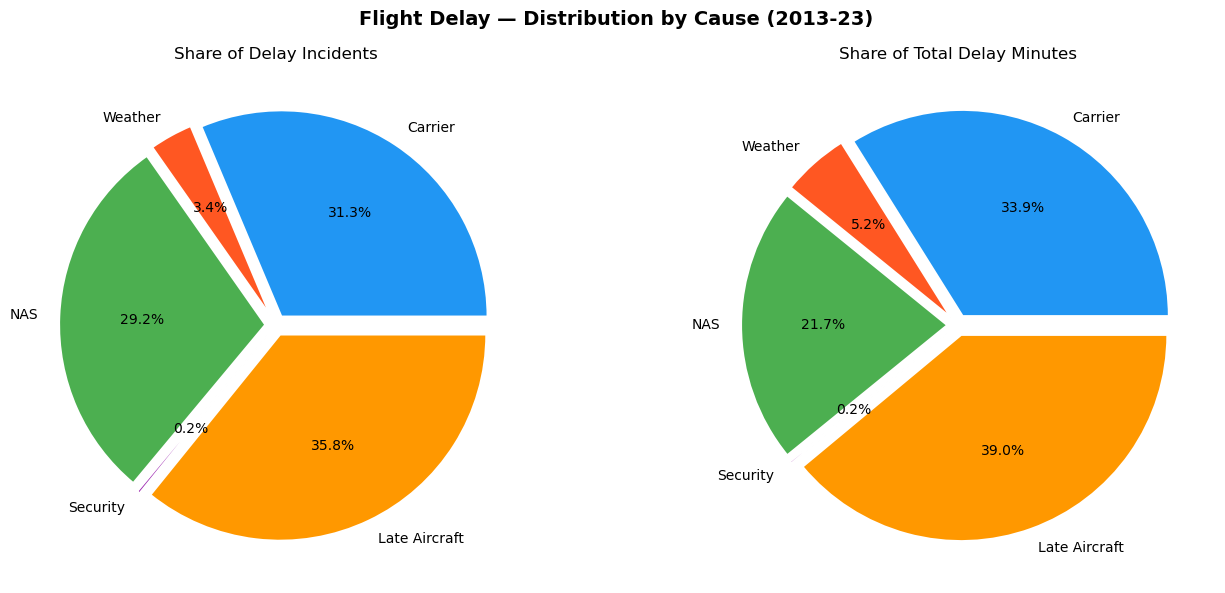

In [5]:
# Overall Cause Distribution

cause_counts = pd.Series({
    'Carrier': df_clean['carrier_ct'].sum(),
    'Weather': df_clean['weather_ct'].sum(),
    'NAS': df_clean['nas_ct'].sum(),
    'Security': df_clean['security_ct'].sum(),
    'Late Aircraft': df_clean['late_aircraft_ct'].sum()
})

cause_minutes = pd.Series({
    'Carrier': df_clean['carrier_delay'].sum(),
    'Weather': df_clean['weather_delay'].sum(),
    'NAS': df_clean['nas_delay'].sum(),
    'Security': df_clean['security_delay'].sum(),
    'Late Aircraft': df_clean['late_aircraft_delay'].sum()
})

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Flight Delay — Distribution by Cause (2013-23)', fontsize=14, fontweight='bold')

# Pie (Incidents)
wedges, texts, autotexts = ax[0].pie(cause_counts, 
            labels = cause_counts.index, 
            autopct = '%1.1f%%', 
            colors = PALETTE,
            explode = [0.05]*5,
            wedgeprops = {'edgecolor':'white','linewidth':1.5}
            )
ax[0].set_title('Share of Delay Incidents')

# Pie (Minutes)
wedges, texts, autotexts = ax[1].pie(cause_minutes, 
            labels = cause_minutes.index, 
            autopct = '%1.1f%%', 
            colors = PALETTE,
            explode = [0.05]*5,
            wedgeprops = {'edgecolor':'white','linewidth':1.5}
            )
ax[1].set_title('Share of Total Delay Minutes')

    
plt.tight_layout()
plt.savefig(SAVE_DIR + '01_delay_cause_pie.png')
plt.show()

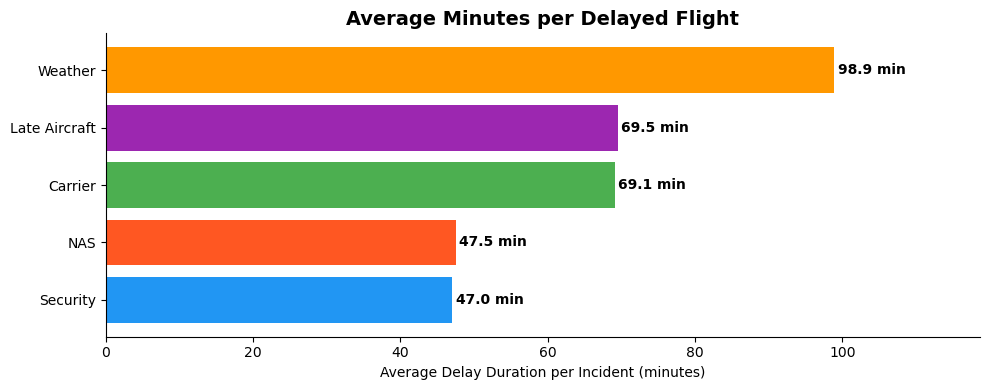

In [6]:
# Bar

avg_per_cause = (cause_minutes / cause_counts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(avg_per_cause.index, 
               avg_per_cause.values, 
               color = PALETTE, 
               )

for bar in bars:
    ax.text(bar.get_width() + 0.5, 
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f} min', 
            va='center',
            fontweight='bold',
            )

ax.set_xlabel('Average Delay Duration per Incident (minutes)')
ax.set_title('Average Minutes per Delayed Flight', fontsize=14, fontweight='bold')
ax.set_xlim(0, avg_per_cause.max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_DIR + '02_delay_cause_bar.png')
plt.show()

### Some insights from above plot
1. Late Aircarft is the most prominent reason.
2. Contrast to general opinion such as weather which is significantly less.
3. Cascading effect for late Aircrafts make it even worse.
4. Carrier Delay is the second most prominent reason.
5. Both the top 2 delays are logistic reasons - need to improve logistics.
5. Security reasons is the least (almost negligible) - no updates needed.

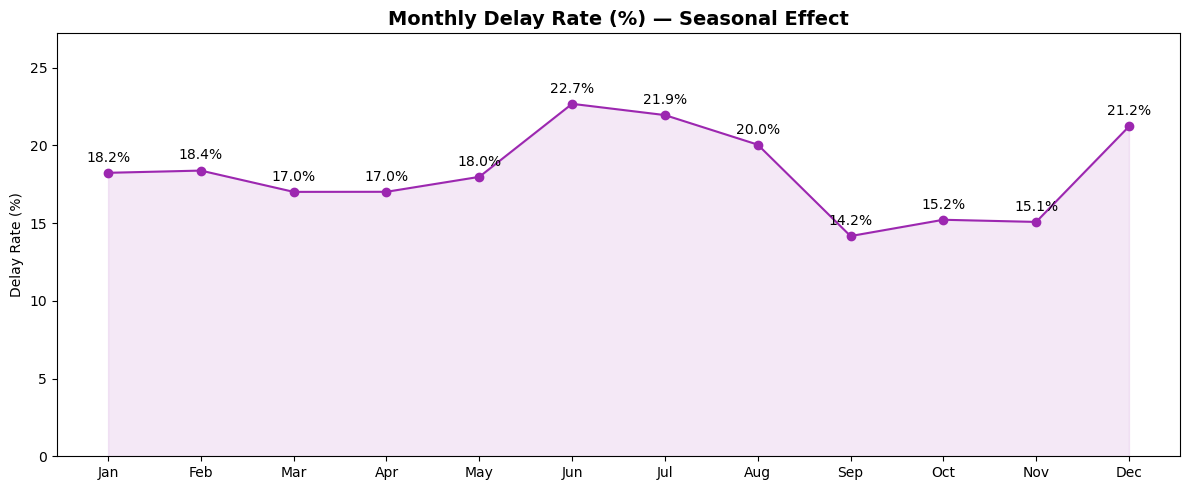

In [7]:
# Monthly Cause Distribution Percentage

# Create aggregator for Month
monthly = df_clean.groupby('month').agg(
    flights = ('arr_flights', 'sum'),
    del15 = ('arr_del15', 'sum'),
    carrier = ('carrier_ct', 'sum'),
    weather = ('weather_ct', 'sum'),
    nas = ('nas_ct', 'sum'),
    security = ('security_ct', 'sum'),
    late_ac = ('late_aircraft_ct', 'sum')
).reset_index()
monthly['delay_rate'] = monthly['del15'] / monthly['flights'] * 100
monthly['month_name'] = monthly['month'].map(month_map)
# print(monthly.head())

fig, ax = plt.subplots(figsize=(12, 5))

# delay rate line
ax.plot(monthly['month_name'], 
           monthly['delay_rate'],
           color = PALETTE[3], 
           marker = 'o',
           )
ax.fill_between(monthly['month_name'], 
                   monthly['delay_rate'],
                   alpha = 0.1, 
                   color = PALETTE[3]
                   )
ax.set_title('Monthly Delay Rate (%) — Seasonal Effect', fontsize=14, fontweight='bold')
ax.set_ylabel('Delay Rate (%)')
ax.set_ylim(0, monthly['delay_rate'].max() * 1.2)
for x, y in zip(monthly['month_name'], monthly['delay_rate']):
    ax.annotate(f'{y:.1f}%', (x, y), 
                    textcoords='offset points',
                    xytext=(0, 8), 
                    ha='center'
                    )

plt.tight_layout()
plt.savefig(SAVE_DIR + '03_monthly_delay_pct.png', bbox_inches='tight')
plt.show()

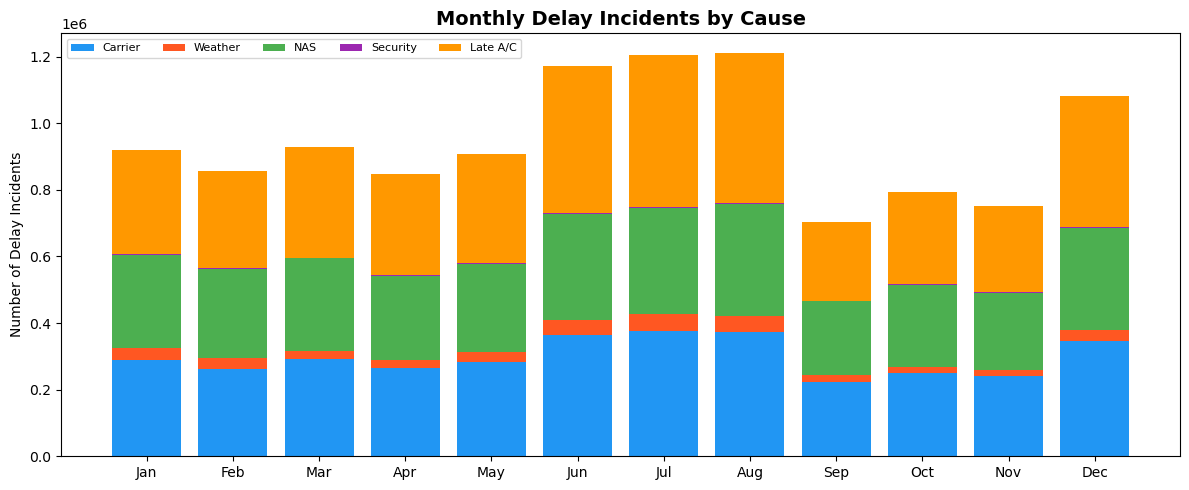

In [8]:
# delay counts bar

fig, ax = plt.subplots(figsize=(12, 5))
cause_cols = ['carrier','weather','nas','security','late_ac']
cause_labels = ['Carrier','Weather','NAS','Security','Late A/C']
bottom = np.zeros(len(monthly))
for col, label, color in zip(cause_cols, cause_labels, PALETTE):
    ax.bar(monthly['month_name'], 
              monthly[col], 
              bottom=bottom,
              label=label, 
              color=color, 
              )
    bottom += monthly[col].values
ax.set_title('Monthly Delay Incidents by Cause', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Delay Incidents')
ax.legend(loc='upper left', fontsize=8, ncol=5)

plt.tight_layout()
plt.savefig(SAVE_DIR + '04_monthly_delay_minutes.png', bbox_inches='tight')
plt.show()

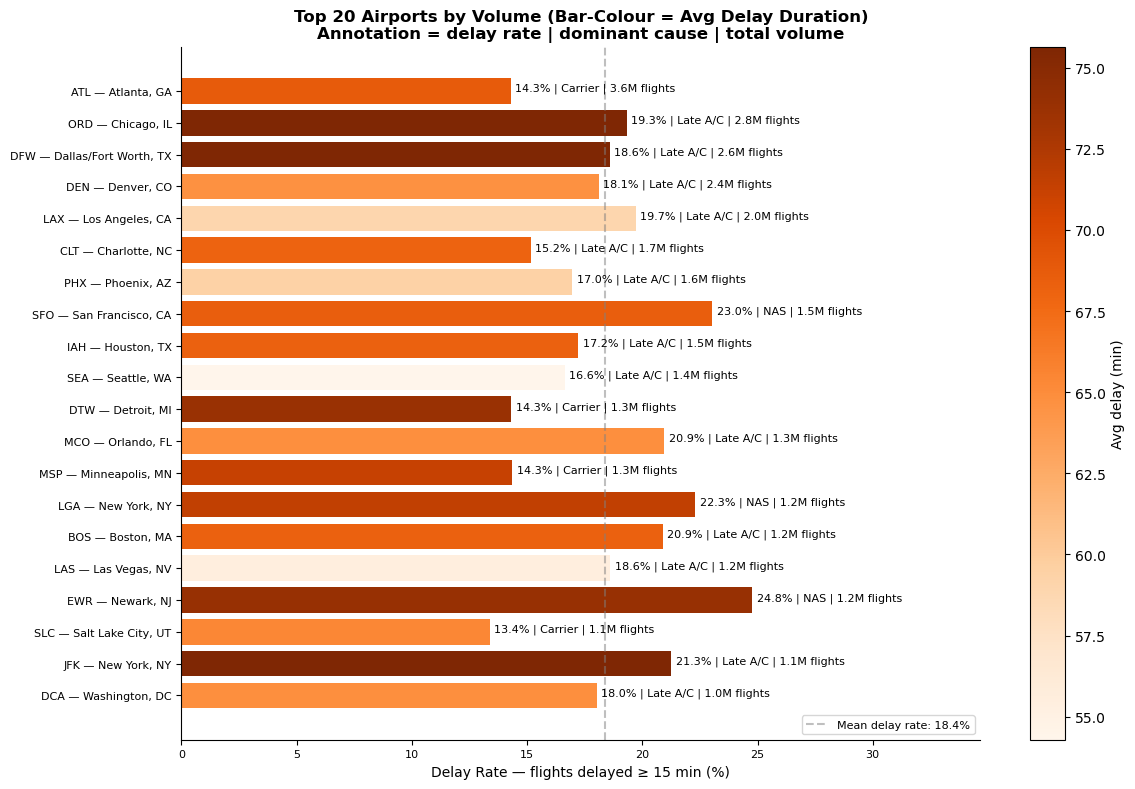

In [10]:
# Airport Profile

# # Create aggregator for Airports
agg_cols_dict = {
    'total_flights': ('arr_flights', 'sum'),
    'total_del15': ('arr_del15', 'sum'),
    'total_delay_m': ('arr_delay', 'sum'),
    'weather_m': ('weather_delay', 'sum'),
    'carrier_m': ('carrier_delay', 'sum'),
    'security_m': ('security_delay', 'sum'),
    'late_ac_m': ('late_aircraft_delay', 'sum'),
    'nas_m': ('nas_delay', 'sum'),
}

ap_agg = df.groupby(['airport', 'airport_name']).agg(**agg_cols_dict).reset_index()

ap_agg['delay_rate']    = ap_agg['total_del15']  / ap_agg['total_flights'] * 100
ap_agg['avg_delay_min'] = ap_agg['total_delay_m'] / ap_agg['total_del15'].replace(0, np.nan)

top20 = (ap_agg.nlargest(20, 'total_flights').sort_values('total_flights', ascending=True))

labels = [f"{row.airport} — {row.airport_name.split(':')[0].strip()[:25]}" for row in top20.itertuples()]

cause_cols   = ['carrier_m', 'weather_m', 'nas_m', 'security_m', 'late_ac_m']
cause_labels = ['Carrier', 'Weather', 'NAS', 'Security', 'Late A/C']
top20['dominant_cause'] = top20[cause_cols].idxmax(axis=1).map({
    'carrier_m': 'Carrier', 
    'weather_m': 'Weather',
    'nas_m': 'NAS',
    'security_m': 'Security',
    'late_ac_m': 'Late A/C'
})
cmap = plt.cm.Oranges
norm = plt.Normalize(top20['avg_delay_min'].min(), top20['avg_delay_min'].max())
colors = [cmap(norm(v)) for v in top20['avg_delay_min']]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(labels, 
               top20['delay_rate'].values, 
               color = colors, 
               )

for bar, (_, row) in zip(bars, top20.iterrows()):
    w = bar.get_width()
    ax.text(w + 0.2, 
            bar.get_y() + bar.get_height() / 2,
            f"{w:.1f}% | {row['dominant_cause']} | {row['total_flights']/1e6:.1f}M flights",
            fontsize=8,
            )
    
# plt.colorbar(plt.cm.Oranges, ax=ax, label='Avg delay (min)')
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, label='Avg delay (min)')


mean_line = top20['delay_rate'].mean()
ax.axvline(mean_line, linestyle='--', label=f'Mean delay rate: {mean_line:.1f}%', color='grey', alpha=0.5)
ax.legend(fontsize=8, loc='lower right')

ax.set_title('Top 20 Airports by Volume (Bar-Colour = Avg Delay Duration)\n'
            'Annotation = delay rate | dominant cause | total volume',
            fontsize=12, fontweight='bold')

ax.set_xlabel('Delay Rate — flights delayed ≥ 15 min (%)')
ax.set_xlim(0, top20['delay_rate'].max() * 1.4)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.savefig(SAVE_DIR + 'top20_airports.png')
plt.show()